# **Dog Breed Prediction**

### **In this project, we will see how to use Keras and TensorFlow to build,train,and test a Convolutional Neural Network capable of identifying the breed of dog in a supplied image. This is a supervised learning problem, specifically a multi-class classification**

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"suckmysinan","key":"f727bbfa2c5f3c547eae384a7a527c3d"}'}

In [ ]:
!pip install -q kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

!chmod 600 ~`/.kaggle/kaggle.json

/bin/bash: -c: line 1: unexpected EOF while looking for matching ``'
/bin/bash: -c: line 2: syntax error: unexpected end of file


**Setting up Kaggle using Kaggle API**

In [ ]:
!mkdir dog_dataset
%cd dog_dataset

/content/dog_dataset


**To store the data we will create a new directory and make it as current working directory.**

In [ ]:
!kaggle datasets list -s dogbreedidfromcomp

ref                                title                         size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------  ----------------------  ----------  --------------------------  -------------  ---------  ---------------  
catherinehorng/dogbreedidfromcomp  dog-breed-id-from-comp   724495926  2020-06-26 03:09:05.433000           8457         10  0.1764706        


**Searching kaggle for the required dataset using search option(-s) with title 'dogbreedfromcomp'. We can also use diffrent search options like searching competitions,notebooks,kernels,datasets,etc.**

In [ ]:
!kaggle datasets download catherinehorng/dogbreedidfromcomp
%cd ..

Dataset URL: https://www.kaggle.com/datasets/catherinehorng/dogbreedidfromcomp
License(s): unknown
 99% 683M/691M [00:11<00:00, 70.7MB/s]
100% 691M/691M [00:11<00:00, 60.9MB/s]
/content


**After searching the data next step would be downloading the data into colab notebook using references found in search option.**

In [ ]:
!unzip dog_dataset/dogbreedidfromcomp.zip -d dog_dataset
!rm dog_dataset/dogbreedidfromcomp.zip
!rm dog_dataset/sample_submission.csv

Streaming output truncated to the last 5000 lines.
  inflating: dog_dataset/train/83bc62b0fffa99a9c94ba0b67a5f7395.jpg  
  inflating: dog_dataset/train/83bcff6b55ee179a7c123fa6103c377a.jpg  
  inflating: dog_dataset/train/83be6d622ab74a5e7e08b53eb8fd566a.jpg  
  inflating: dog_dataset/train/83c2d7419b0429b9fe953bc1b6cddbec.jpg  
  inflating: dog_dataset/train/83cf7d7cd2a759a93e2ffd95bea9c6fb.jpg  
  inflating: dog_dataset/train/83d405858f0931722ef21e8ac0adee4d.jpg  
  inflating: dog_dataset/train/83d4125a4c3c7dc5956563276cb1cd74.jpg  
  inflating: dog_dataset/train/83f0bb565b2186dbcc6a9d009cb26ff2.jpg  
  inflating: dog_dataset/train/83fad0718581a696132c96c166472627.jpg  
  inflating: dog_dataset/train/83fbbcc9a612e3f712b1ba199da61f20.jpg  
  inflating: dog_dataset/train/8403d8936430c2f05ab7d74d23c2c0cb.jpg  
  inflating: dog_dataset/train/8406d837b2d7fac1c3cd621abb4c4f9e.jpg  
  inflating: dog_dataset/train/840b67d26e5e43f8eb6430f62d4ba1ac.jpg  
  inflating: dog_dataset/train/840db91b

We will unzip the data which is downloaded and remove the irrelevant files.

In [ ]:
# Important library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from keras.preprocessing import image
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import Adam

In [ ]:
labels_all = pd.read_csv('dog_dataset/labels.csv')
print(labels_all.shape)
labels_all.head

(10222, 2)


<bound method NDFrame.head of                                      id                     breed
0      000bec180eb18c7604dcecc8fe0dba07               boston_bull
1      001513dfcb2ffafc82cccf4d8bbaba97                     dingo
2      001cdf01b096e06d78e9e5112d419397                  pekinese
3      00214f311d5d2247d5dfe4fe24b2303d                  bluetick
4      0021f9ceb3235effd7fcde7f7538ed62          golden_retriever
...                                 ...                       ...
10217  ffd25009d635cfd16e793503ac5edef0                    borzoi
10218  ffd3f636f7f379c51ba3648a9ff8254f            dandie_dinmont
10219  ffe2ca6c940cddfee68fa3cc6c63213f                  airedale
10220  ffe5f6d8e2bff356e9482a80a6e29aac        miniature_pinscher
10221  fff43b07992508bc822f33d8ffd902ae  chesapeake_bay_retriever

[10222 rows x 2 columns]>

In [ ]:
# Visualize the number of each breeds
breeds_all = labels_all["breed"]
breed_counts = breeds_all.value_counts()
breed_counts.head()

,count
breed,
scottish_deerhound,126
maltese_dog,117
afghan_hound,116
entlebucher,115
bernese_mountain_dog,114


**Here we are finding out the count per class i.e total data in each class using value_counts() function.**

In [ ]:
# Selecting first 3 breeds (Limitation due to computation power)
CLASS_NAMES  = ['scottish_deerhound','maltese_dog','bernese_mountain_dog']
labels = labels_all[labels_all['breed'].isin(CLASS_NAMES)]
labels = labels.reset_index()
labels.head()

,index,id,breed
0,9,0042188c895a2f14ef64a918ed9c7b64,scottish_deerhound
1,12,00693b8bc2470375cc744a6391d397ec,maltese_dog
2,79,01e787576c003930f96c966f9c3e1d44,scottish_deerhound
3,90,022b34fd8734b39995a9f38a4f3e7b6b,maltese_dog
4,118,02d54f0dfb40038765e838459ae8c956,bernese_mountain_dog


In [ ]:
# Creating numpy matrix with zeros
X_data = np.zeros((len(labels), 224, 224, 3), dtype='float32')
# One hot encoding
Y_data = label_binarize(labels['breed'], classes = CLASS_NAMES)

# Reading and coverting image to numpy array and normalizing dataset

for i in tqdm(range(len(labels))):
  img = image.load_img('dog_dataset/train/%s.jpg' % labels['id'][i], target_size=(224, 224))
  img = image.img_to_array(img)
  x = np.expand_dims(img.copy(), axis=0)
  X_data[i] = x / 255.0

# Printing train image and one hot encode shape & size
print('\nTrain Images shape: ',X_data.shape,' size: {:,}'.format(X_data.size))
print('One-hot encoded output shape: ',Y_data.shape,' size: {:,}'.format(Y_data.size))

100%|██████████| 357/357 [00:01<00:00, 355.47it/s]


Train Images shape:  (357, 224, 224, 3)  size: 53,738,496
One-hot encoded output shape:  (357, 3)  size: 1,071


In [ ]:
# Building the Model

model = Sequential()

model.add(Conv2D(filters=64, kernel_size=(5,5), activation='relu', input_shape=(224,224,3)))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', kernel_regularizer='l2'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=16, kernel_size=(7,7), activation='relu', kernel_regularizer='l2'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=8, kernel_size=(5,5), activation='relu', kernel_regularizer='l2'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation="relu", kernel_regularizer='l2'))
model.add(Dense(64, activation="relu", kernel_regularizer='l2'))
model.add(Dense(len(CLASS_NAMES), activation="softmax"))

model.compile(loss='categorical_crossentropy',optimizer=Adam(0.0001),metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 220, 220, 64)   │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 108, 108, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 16)     │        25,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 8)      │         3,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,619 (635.23 KB)

 Trainable params: 162,619 (635.23 KB)

 Non-trainable params: 0 (0.00 B)

**Next we will create a network architecture for the model. We have used difffrent types of layers according to their features namely Conv_2d (it is used to create a convolutional kernel that is convolved with the input layer to produce the output tensor), max_poolin2d (it is a downsampling technique which takes out the maximum value over the window defined by poolsize), flatten (it flattens the input and creates a 1D output), Dense (Dense layer produce the output as the dot product of input and kernel).**

In [ ]:
# Splitting the data set into training and testing data sets
X_train_and_val, X_test, Y_train_and_val, Y_test = train_test_split(X_data, Y_data, test_size = 0.1)
# Splitting the training data set into training and validation data sets
X_train, X_val, Y_train, Y_val = train_test_split(X_train_and_val, Y_train_and_val, test_size = 0.2)

**After defining the network architecture we will start with splitting the test and train data then dividing train data in train and validation data.**

In [23]:
# Training the model
epochs = 100
batch_size = 128

history = model.fit(X_train, Y_train, batch_size = batch_size, epochs = epochs, validation_data = (X_val, Y_val))

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 40s 18s/step - accuracy: 0.2214 - loss: 4.9159 - val_accuracy: 0.3538 - val_loss: 4.8728
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 37s 18s/step - accuracy: 0.2526 - loss: 4.8811 - val_accuracy: 0.3846 - val_loss: 4.8508
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 37s 21s/step - accuracy: 0.2656 - loss: 4.8527 - val_accuracy: 0.3692 - val_loss: 4.8303
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 37s 18s/step - accuracy: 0.3802 - loss: 4.8283 - val_accuracy: 0.4769 - val_loss: 4.8081
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 41s 18s/step - accuracy: 0.4453 - loss: 4.8043 - val_accuracy: 0.4462 - val_loss: 4.7857
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 40s 18s/step - accuracy: 0.4583 - loss: 4.7807 - val_accuracy: 0.4615 - val_loss: 4.7624
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 33s 18s/step - accuracy: 0.5026 - loss: 4.7560 - val_accuracy: 0.4154 - val_loss: 4.7395
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 35s 19s/step - accuracy: 0.4974 - loss: 4.7316 - val_accuracy: 0.3846 - val_loss:

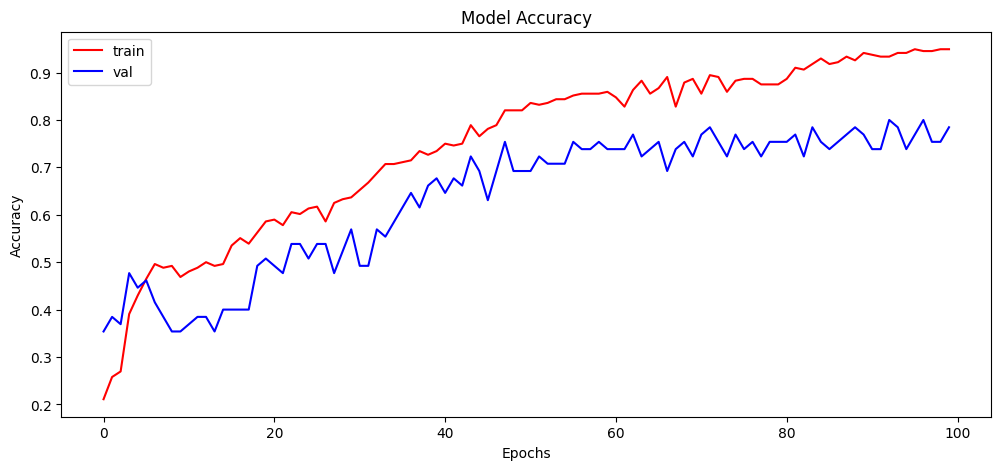

In [24]:
# Plot the training history
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], color='r')
plt.plot(history.history['val_accuracy'], color='b')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'val'])

plt.show()

**Here we analyse how the model is learning with each epoch in terms of accuracy.**

In [27]:
Y_pred = model.predict(X_test)
score = model.evaluate(X_test, Y_test)
print('Acuracy over the test set: \n', f'{round(score[1]*100, 2)}%')

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 343ms/step - accuracy: 0.6343 - loss: 3.1486
Acuracy over the test set: 
 63.89%


**We will use predict function to make predictions using this model also we are finding out the accuracy on the test set.**

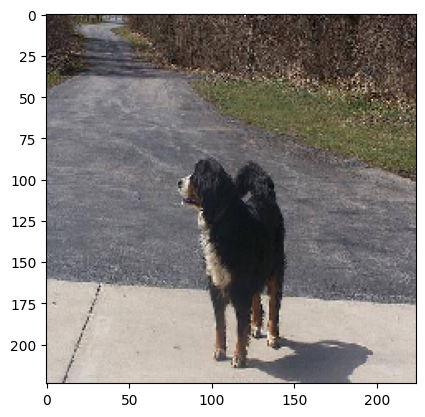

Originally :  scottish_deerhound
Predicted :  scottish_deerhound


In [30]:
# Plotting image to compare
plt.imshow(X_test[1,:,:,:])
plt.show()

#Finding max value from prediction list and comparing original value vs predicted
print("Originally : ",labels['breed'][np.argmax(Y_test[1])])
print("Predicted : ",labels['breed'][np.argmax(Y_pred[1])])

# **Conclusion**

### We started with downloading the dataset creating the model and finding out the predictions using the model. We can optimize diffrent hyper parameters in order to tune this model for a higher accuracy. This model can be used to predict diffrent breeds of dogs which can be further used by diffrent Ngo's working on saving animals and for educational purpose

In [31]:
model.save("dog_breed.h5")